# Importing Pandas and loading the data

In [1]:
import pandas as pd
import numpy as np
import re

orders_df = pd.read_csv('orders.csv')
orderlines_df = pd.read_csv('orderlines.csv')
products_df = pd.read_csv('products.csv')
brands_df = pd.read_csv('brands.csv')

In [2]:
def clean_unit_prices(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # keep only numbers, '.' and ',' 
    s = re.sub(r"[^0-9\.,]", "", s)

    # convert ',' to '.'
    s = s.replace(",", ".")

    # keep only the last '.'
    if s.count(".") > 1:
        parts = s.split(".")
        s = "".join(parts[:-1]) + "." + parts[-1]
    
    # convert to float
    try:
        val = float(s)
    except:
        return np.nan

    return str(val)

In [3]:
def clean_prices_v2(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    # keep only numbers, '.' and ',' 
    s = re.sub(r"[^0-9\.,]", "", s)
    # convert ',' to '.'
    s = s.replace(",", ".")

    # keep only the last '.'
    if s.count(".") > 1:
        parts = s.split(".")
        s = "".join(parts[:-1]) + "." + parts[-1]

    # convert to float
    try:
        val = float(s)
    except:
        return np.nan

    # if num of digits after '.' is 3, the divide by 10
    if "." in s:
        dec = s.split(".")[-1]
        if len(dec) == 3:
            val = val / 10

    return str(round(val,2))

In [4]:
def clean_still_bad_promo_prices(x):
    
    #divide by 10
    return round(x/10 , 2)

## Making copies

In [5]:
or_df = orders_df.copy()
ol_df = orderlines_df.copy()
pr_df = products_df.copy()
br_df = brands_df.copy()

# Data Cleaning :

## Cleaning Orders DataFrame :

We are interested only in Completed Orders

In [6]:
or_df.shape

(226909, 4)

In [7]:
or_df['state'].value_counts(normalize=True)

state
Shopping Basket    0.519191
Completed          0.205391
Place Order        0.180174
Pending            0.063369
Cancelled          0.031876
Name: proportion, dtype: float64

In [8]:
or_df = or_df.loc[or_df['state'] == 'Completed']
or_df.info()

<class 'pandas.DataFrame'>
Index: 46605 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      46605 non-null  int64  
 1   created_date  46605 non-null  str    
 2   total_paid    46605 non-null  float64
 3   state         46605 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.8 MB


In [9]:
# converting created_date to datetime in orders DF
or_df['created_date'] = pd.to_datetime(or_df['created_date'])
or_df.info()

<class 'pandas.DataFrame'>
Index: 46605 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      46605 non-null  int64         
 1   created_date  46605 non-null  datetime64[us]
 2   total_paid    46605 non-null  float64       
 3   state         46605 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 1.8 MB


In [10]:
# checking for duplicates :
or_df.duplicated().sum()

np.int64(0)

## Cleaning Order Lines DataFrame :

In [11]:
ol_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                293983 non-null  int64
 1   id_order          293983 non-null  int64
 2   product_id        293983 non-null  int64
 3   product_quantity  293983 non-null  int64
 4   sku               293983 non-null  str  
 5   unit_price        293983 non-null  str  
 6   date              293983 non-null  str  
dtypes: int64(4), str(3)
memory usage: 15.7 MB


In [12]:
# checking for duplicates :
ol_df.duplicated().sum()

np.int64(0)

In [13]:
ol_df['date'] = pd.to_datetime(ol_df['date'])

In [14]:
# let's check Unit prices
mask = (ol_df['unit_price'].str.contains(r"\d+\.\d+\.\d+")) |(ol_df['unit_price'].str.contains(r"\d+\.\d{3,}"))
bad_rows = ol_df.loc[mask]
bad_rows

,id,id_order,product_id,product_quantity,sku,unit_price,date
6,1119115,299544,0,1,APP1582,1.137.99,2017-01-01 01:17:21
11,1119126,299549,0,1,PAC0929,2.565.99,2017-01-01 02:07:42
15,1119131,299553,0,1,APP1854,3.278.99,2017-01-01 02:14:47
43,1119195,299582,0,1,PAC0961,2.616.99,2017-01-01 08:54:00
59,1119214,299596,0,1,PAC1599,2.873.99,2017-01-01 09:53:11
...,...,...,...,...,...,...,...
293862,1649999,452946,0,1,APP2075,2.999.00,2018-03-14 13:03:33
293887,1650045,527321,0,1,PAC2148,3.497.00,2018-03-14 13:10:15
293889,1650050,527324,0,1,PAC2117,3.075.00,2018-03-14 13:10:56
293911,1650088,527342,0,1,APP2492,1.329.00,2018-03-14 13:24:51


In [15]:
print(f'we have to drop {bad_rows['id_order'].nunique()}')

we have to drop 34642


In [16]:
# we need to drop them (the whole order not just the order line)
ol_df = ol_df.loc[~ol_df['id_order'].isin(bad_rows['id_order'])]
ol_df.info()

<class 'pandas.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  str           
 5   unit_price        216250 non-null  str           
 6   date              216250 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 13.2 MB


In [17]:
ol_df['unit_price'] = pd.to_numeric(ol_df['unit_price'])
ol_df.info()

<class 'pandas.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  str           
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 13.2 MB


## Cleaning Products DataFrame : 

In [18]:
pr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          19326 non-null  str  
 1   name         19326 non-null  str  
 2   desc         19319 non-null  str  
 3   price        19280 non-null  str  
 4   promo_price  19326 non-null  str  
 5   in_stock     19326 non-null  int64
 6   type         19276 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.0 MB


In [19]:
# checking for duplicates :
pr_df.duplicated('sku').sum()

np.int64(8747)

In [20]:
# from previos cell we can see that we have duplicated SKU we need to drop them
pr_df = pr_df.drop_duplicates(subset=['sku'],ignore_index=True)
pr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10579 entries, 0 to 10578
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          10579 non-null  str  
 1   name         10579 non-null  str  
 2   desc         10572 non-null  str  
 3   price        10534 non-null  str  
 4   promo_price  10579 non-null  str  
 5   in_stock     10579 non-null  int64
 6   type         10529 non-null  str  
dtypes: int64(1), str(6)
memory usage: 578.7 KB


In [21]:
pr_df['sku'].nunique()

10579

In [22]:
# checking null values
pr_df.isnull().sum()

sku             0
name            0
desc            7
price          45
promo_price     0
in_stock        0
type           50
dtype: int64

In [23]:
# null values in desc and type columns
pr_df['desc'] = pr_df['desc'].fillna(pr_df['name'])
pr_df['type'] = pr_df['type'].fillna('unknwon')
pr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10579 entries, 0 to 10578
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          10579 non-null  str  
 1   name         10579 non-null  str  
 2   desc         10579 non-null  str  
 3   price        10534 non-null  str  
 4   promo_price  10579 non-null  str  
 5   in_stock     10579 non-null  int64
 6   type         10579 non-null  str  
dtypes: int64(1), str(6)
memory usage: 578.7 KB


In [24]:
# null values in price column
pr_df.loc[pr_df['price'].isna()].shape[0]

45

In [25]:
# let's drop them
pr_df = pr_df.dropna(subset='price')

In [26]:
pr_df.isna().sum()

sku            0
name           0
desc           0
price          0
promo_price    0
in_stock       0
type           0
dtype: int64

In [27]:
pr_df.info()

<class 'pandas.DataFrame'>
Index: 10534 entries, 0 to 10578
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          10534 non-null  str  
 1   name         10534 non-null  str  
 2   desc         10534 non-null  str  
 3   price        10534 non-null  str  
 4   promo_price  10534 non-null  str  
 5   in_stock     10534 non-null  int64
 6   type         10534 non-null  str  
dtypes: int64(1), str(6)
memory usage: 658.4 KB


In [28]:
# we can't convert price to numeric , we need to drop them: 
# let's see how many products have bad price value
bad_prices = pr_df.loc[(pr_df.price.str.contains(r"\d+\.\d+\.\d+"))|(pr_df.price.str.contains(r"\d+\.\d{3,}"))]
bad_prices

,sku,name,desc,price,promo_price,in_stock,type
202,REP0043,Speaker lower repair iPhone 4,Repair service including parts and labor for i...,499.004,499.004,0,"1,44E+11"
320,PIE0011,Internal Battery for iPhone 3G,Replacement AC Adapter for Apple iPhone 3G.,98.978,98.978,0,21485407
355,SEN0061,Sennheiser EZX 80 Handsfree iPhone iPad and iP...,IPhone bluetooth headset with microphone iPad ...,649.891,649.891,0,5384
358,SEV0026,Service installation RAM + HDD + SSD MacBook /...,RAM + HDD installation + SSD in your MacBook /...,599.918,599.918,0,20642062
365,SEV0024,Service installation RAM + HDD + SSD Mac mini,installation RAM HDD + SSD + on your Mac mini ...,599.918,599.918,0,20642062
...,...,...,...,...,...,...,...
10565,REP0424,Input repair Headphones iPad,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"
10566,REP0421,iPad charging connector repair,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"
10567,REP0416,iPad front camera repair,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"
10568,REP0413,repair rear camera iPad,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"


In [29]:
pr_df = pr_df.loc[~pr_df['sku'].isin(bad_prices['sku'])]

In [30]:
pr_df['price'] = pd.to_numeric(pr_df['price'])

In [31]:
pr_df.info()

<class 'pandas.DataFrame'>
Index: 9992 entries, 0 to 10578
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          9992 non-null   str    
 1   name         9992 non-null   str    
 2   desc         9992 non-null   str    
 3   price        9992 non-null   float64
 4   promo_price  9992 non-null   str    
 5   in_stock     9992 non-null   int64  
 6   type         9992 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 624.5 KB


In [32]:
# checking promo prices
pr_df.loc[pr_df['promo_price'].str.contains(r'[A-Za-z0-9]+\.[A-Za-z0-9]+\.[A-Za-z0-9]+')]

,sku,name,desc,price,promo_price,in_stock,type
50,APP0367,Apple Mini DisplayPort to DVI Adapter Mac dual...,Adapter Mini Display Port to DVI dual channel ...,119.00,1.119.976,0,1325
51,APP0344,"Apple Thunderbolt Display 27 ""Monitor Mac",Monitor Display 27-inch Apple Thunderbolt (MC9...,1149.00,10.449.923,0,1296
66,MAK0008,Maclocks theft case iPad 2 3 and 4 black with ...,Case antitheft iPad 2 3 and 4 polycarbonate ro...,120.00,1.199.957,0,12635403
67,MAK0007,Maclocks theft case iPad 2 3 and 4 transparent...,Case antitheft iPad 2 3 and 4 polycarbonate ro...,120.00,1.079.961,0,12635403
97,MAK0014,Maclocks safety housing Kiosk iPad 2 3 and 4 b...,Holder and housing iPad 2 3 and 4 aluminum and...,164.99,1.649.896,0,1216
...,...,...,...,...,...,...,...
10553,REP0412,Rear Camera Repair iPhone 7 Plus,It is including parts and labor for iPhone 7 Plus,119.99,1.199.897,0,"1,44E+11"
10570,REP0403,iPad LCD screen repair,Repair service including parts and labor for iPad,159.99,1.599.898,0,"1,44E+11"
10571,REP0402,iPad touch screen repair,Repair service including parts and labor for iPad,139.99,1.399.897,0,"1,44E+11"
10572,KNO0032,"Knomo MacBook Pro Beauchamp Backpack 14 ""Black",Backpack thin nylon mesh internal compartment ...,179.00,1.699.905,1,1392


In [33]:
# droping 4,307 rows from 9,992 does not make any sense !!!
# that is almost 42% of our data !!
# let's ignore that for now...we'll try to fix that later in Data Quality phase.

# Data Quality : 

## Droping order lines & orders with unknown products : 

In [34]:
# let's check if all products in order_lines DF appear in Products DF
temp = ol_df.loc[~ol_df['sku'].isin(pr_df['sku'])]
temp

,id,id_order,product_id,product_quantity,sku,unit_price,date
38,1119186,299576,0,1,SAM0095,82.64,2017-01-01 06:51:23
117,1119316,299638,0,1,SYN0127,223.24,2017-01-01 11:56:18
183,1119447,299695,0,1,PAC1400,90.99,2017-01-01 13:27:15
192,1119477,299706,0,1,EVU0007,28.49,2017-01-01 13:57:16
198,1119494,299712,0,1,APP0608,279.99,2017-01-01 14:10:47
...,...,...,...,...,...,...,...
293688,1649659,527147,0,1,SEV0024,59.99,2018-03-14 12:05:02
293723,1649720,527170,0,1,SEV0024,59.99,2018-03-14 12:16:05
293739,1649748,527191,0,1,FIB0007,99.99,2018-03-14 12:19:19
293942,1650146,527367,0,1,REP0250,69.90,2018-03-14 13:39:34


In [35]:
pr_df.loc[pr_df['sku'].isin(temp['sku'])]

,sku,name,desc,price,promo_price,in_stock,type


In [36]:
# this means we need to drop the whole order not just one line from the order 
temp['id_order'].nunique()

6328

now we need to delete these orders(the whole order) from order lines and from orders 

In [37]:
# deleting from orders 
or_df = or_df.loc[~or_df['order_id'].isin(temp['id_order'])]
or_df.info()

<class 'pandas.DataFrame'>
Index: 45242 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      45242 non-null  int64         
 1   created_date  45242 non-null  datetime64[us]
 2   total_paid    45242 non-null  float64       
 3   state         45242 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 1.7 MB


In [38]:
# deleting from order lines 
ol_df = ol_df.loc[~ol_df['id_order'].isin(temp['id_order'])]
ol_df.info()

<class 'pandas.DataFrame'>
Index: 205580 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                205580 non-null  int64         
 1   id_order          205580 non-null  int64         
 2   product_id        205580 non-null  int64         
 3   product_quantity  205580 non-null  int64         
 4   sku               205580 non-null  str           
 5   unit_price        205580 non-null  float64       
 6   date              205580 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 12.5 MB


## Droping never sold products :

In [39]:
# so that we are interested in sold/(in completed orders) products
# let us drop never sold products
never_sold_products = pr_df.loc[~pr_df['sku'].isin(ol_df['sku'])]
never_sold_products

,sku,name,desc,price,promo_price,in_stock,type
6,KIN0008,Mac Memory Kingston 1GB 667MHz DDR2 SO-DIMM,1GB RAM Mac mini and iMac (2006/07) MacBook Pr...,18.99,146.471,0,1364
11,SEN0021,Sennheiser CX 300-II Precision headphones iPho...,Headphones iPhone iPad iPad 2 iPad 3 and iPod.,49.99,449.878,0,5384
21,APP0233,Apple iPad Camera Connection connector,IPad connector for digital cameras and SD cards.,35.00,349.896,0,13955395
22,JMO0014,Just Mobile Upstand iPad support,Support Retina iPad and iPad mini aluminum.,49.95,399.905,0,1216
23,MOB0007,Mobee Magic Charger Charger Magic Mouse,Wireless Charger for Magic Mouse,49.99,499.851,0,12355400
...,...,...,...,...,...,...,...
10574,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,269.903,1,12282
10575,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,649.903,1,1392
10576,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,649.903,1,1392
10577,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,649.903,0,1392


In [40]:
pr_df = pr_df.loc[~pr_df['sku'].isin(never_sold_products['sku'])]
pr_df.info()

<class 'pandas.DataFrame'>
Index: 6411 entries, 0 to 10573
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          6411 non-null   str    
 1   name         6411 non-null   str    
 2   desc         6411 non-null   str    
 3   price        6411 non-null   float64
 4   promo_price  6411 non-null   str    
 5   in_stock     6411 non-null   int64  
 6   type         6411 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 400.7 KB


In [41]:
ol_df['sku'].nunique()

6411

In [42]:
pr_df['sku'].nunique()

6411

In [43]:
or_df.info()

<class 'pandas.DataFrame'>
Index: 45242 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      45242 non-null  int64         
 1   created_date  45242 non-null  datetime64[us]
 2   total_paid    45242 non-null  float64       
 3   state         45242 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 1.7 MB


In [44]:
ol_df.info()

<class 'pandas.DataFrame'>
Index: 205580 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                205580 non-null  int64         
 1   id_order          205580 non-null  int64         
 2   product_id        205580 non-null  int64         
 3   product_quantity  205580 non-null  int64         
 4   sku               205580 non-null  str           
 5   unit_price        205580 non-null  float64       
 6   date              205580 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 12.5 MB


In [45]:
pr_df.info()

<class 'pandas.DataFrame'>
Index: 6411 entries, 0 to 10573
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          6411 non-null   str    
 1   name         6411 non-null   str    
 2   desc         6411 non-null   str    
 3   price        6411 non-null   float64
 4   promo_price  6411 non-null   str    
 5   in_stock     6411 non-null   int64  
 6   type         6411 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 400.7 KB


## Price Outliers...

In [46]:
ol_df_copy = ol_df.copy()

ol_df_copy['row_total'] = ol_df_copy['product_quantity']*ol_df_copy['unit_price']

ol_df_copy

,id,id_order,product_id,product_quantity,sku,unit_price,date,row_total
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19,18.99
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45,399.00
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57,474.05
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40,68.39
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38,23.74
...,...,...,...,...,...,...,...,...
293978,1650199,527398,0,1,JBL0122,42.99,2018-03-14 13:57:25,42.99
293979,1650200,527399,0,1,PAC0653,141.58,2018-03-14 13:57:34,141.58
293980,1650201,527400,0,2,APP0698,9.99,2018-03-14 13:57:41,19.98
293981,1650202,527388,0,1,BEZ0204,19.99,2018-03-14 13:58:01,19.99


In [47]:
grouped_ol = ol_df_copy.groupby('id_order', as_index=False).agg(order_total = ('row_total','sum'))
grouped_ol

,id_order,order_total
0,241319,44.99
1,241355,135.98
2,241423,129.16
3,242832,10.77
4,243330,77.99
...,...,...
163880,527397,42.99
163881,527398,42.99
163882,527399,141.58
163883,527400,19.98


In [48]:
or_df_merge = or_df.merge(grouped_ol , left_on='order_id', right_on='id_order', how='inner') 
or_df_merge.sort_values('order_id')[['order_id', 'total_paid', 'order_total']]

,order_id,total_paid,order_total
0,241423,136.15,129.16
1,242832,15.76,10.77
2,243330,84.98,77.99
3,245275,149.00,149.00
4,245595,112.97,105.98
...,...,...,...
41696,527042,18.98,13.99
41697,527070,24.97,19.98
41698,527074,24.97,19.98
41699,527096,34.96,29.97


In [49]:
or_df_merge['diff'] = or_df_merge['total_paid'] - or_df_merge['order_total']
or_df_merge

,order_id,created_date,total_paid,state,id_order,order_total,diff
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
...,...,...,...,...,...,...,...
41696,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99,4.99
41697,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98,4.99
41698,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98,4.99
41699,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97,4.99


In [50]:
or_df_merge['diff'].describe()

count    41701.000000
mean         4.474808
std         26.046478
min       -165.000000
25%          0.000000
50%          4.990000
75%          6.990000
max       3984.990000
Name: diff, dtype: float64

In [51]:
or_df_merge['diff'].mean().round(2)

np.float64(4.47)

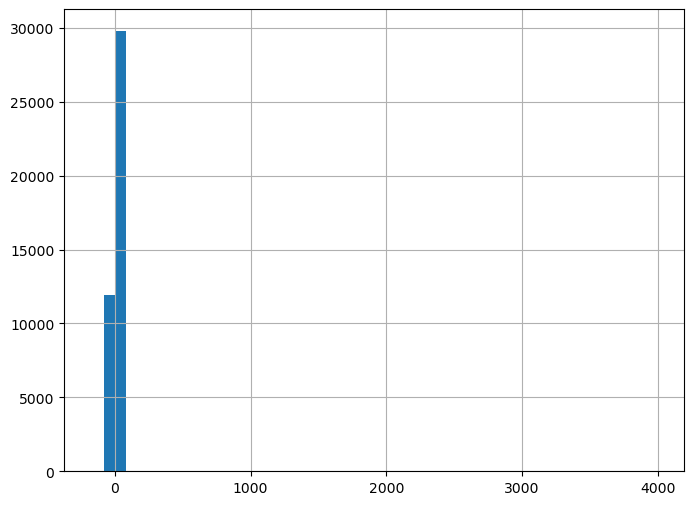

In [52]:
or_df_merge['diff'].hist(bins= 50, figsize=(8,6));

(-30.0, 30.0)

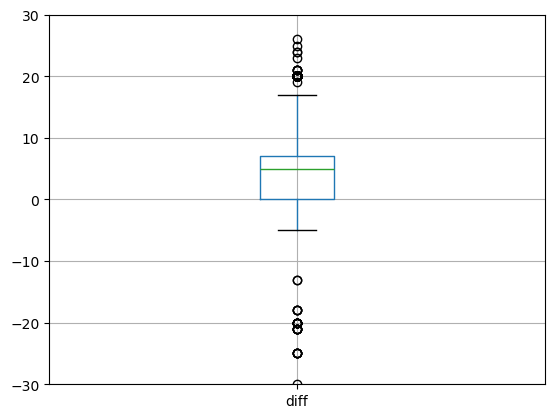

In [53]:
or_df_merge.boxplot('diff').set_ylim(-30, +30)

In [54]:
# IQR & Boundaries :
Q1 = or_df_merge['diff'].quantile(0.25)
Q3 = or_df_merge['diff'].quantile(0.75)
IQR = Q3 - Q1
LB = Q1 - 1.5*IQR
HB = Q3 + 1.5*IQR

Q1,Q3,IQR,LB,HB

(np.float64(0.0),
 np.float64(6.989999999999981),
 np.float64(6.989999999999981),
 np.float64(-10.484999999999971),
 np.float64(17.47499999999995))

In [55]:
or_df_merge_no_outlirs = or_df_merge.loc[or_df_merge['diff'].between(LB,HB)]
or_df_merge_no_outlirs

,order_id,created_date,total_paid,state,id_order,order_total,diff
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
...,...,...,...,...,...,...,...
41696,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99,4.99
41697,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98,4.99
41698,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98,4.99
41699,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97,4.99


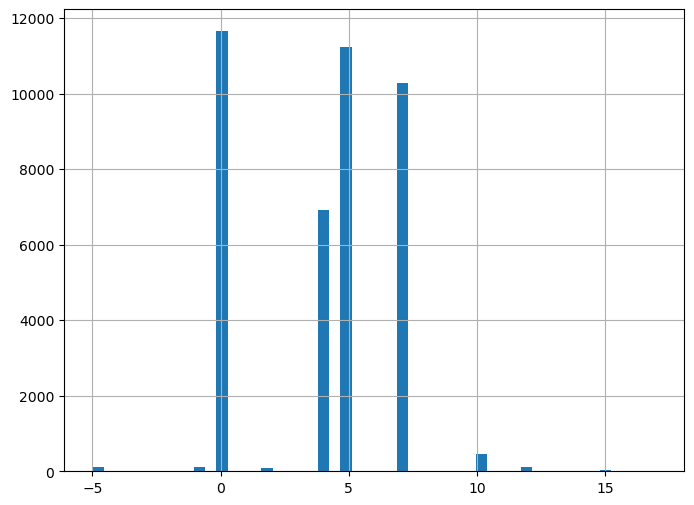

In [56]:
or_df_merge_no_outlirs['diff'].hist(bins= 50, figsize=(8,6));

(-30.0, 30.0)

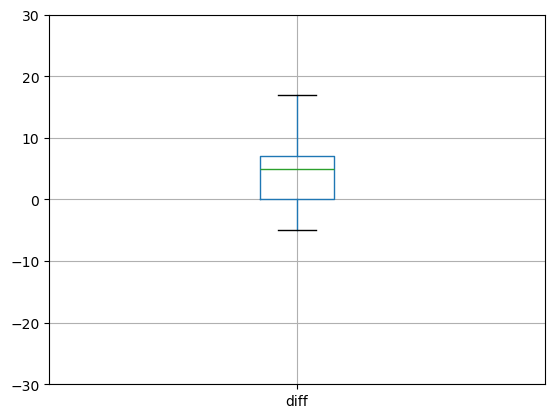

In [57]:
or_df_merge_no_outlirs.boxplot('diff').set_ylim(-30, +30)

In [58]:
or_df = or_df.loc[or_df['order_id'].isin(or_df_merge_no_outlirs['order_id'])]
ol_df = ol_df.loc[ol_df['id_order'].isin(or_df_merge_no_outlirs['order_id'])]

In [59]:
or_df.info()

<class 'pandas.DataFrame'>
Index: 40985 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40985 non-null  int64         
 1   created_date  40985 non-null  datetime64[us]
 2   total_paid    40985 non-null  float64       
 3   state         40985 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 1.6 MB


In [60]:
ol_df['id_order'].nunique()

40985

# Export the data....

In [61]:
# now let's export our new clean DataFrames
ol_df.to_csv('../Analysing/order_lines_new.csv', index= False, encoding='utf-8', na_rep='N/A')
or_df.to_csv('../Analysing/orders_new.csv', index= False, encoding='utf-8', na_rep='N/A')
pr_df.to_csv('../Analysing/products_new.csv', index= False, encoding='utf-8', na_rep='N/A')
br_df.to_csv('../Analysing/brands_new.csv', index= False, encoding='utf-8', na_rep='N/A')